In [2]:
import pandas as pd
import numpy as np
import logging
import warnings 
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
df=pd.read_csv("data/data.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names and Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Info:")
print(df.info())

Dataset Shape: (10000, 14)

Column Names and Types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Basic Statistics:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.0

In [6]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['AgeGroup'].value_counts()   

AgeGroup
35-44    3981
25-34    3222
45-54    1458
55-64     600
18-24     457
65+       282
Name: count, dtype: int64

In [7]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


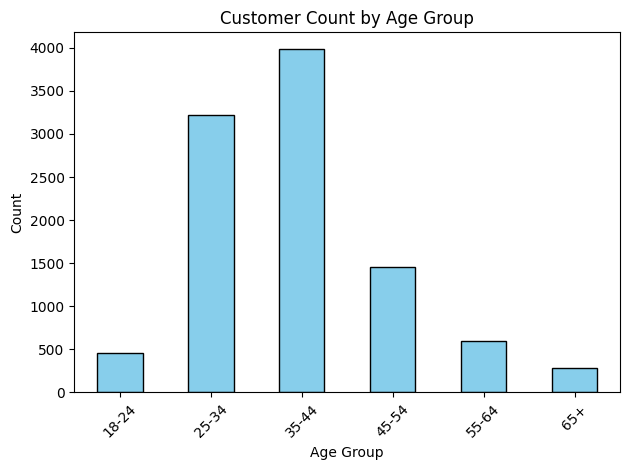

In [8]:
age_counts = df['AgeGroup'].value_counts().reindex(labels)
age_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.title('Customer Count by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()

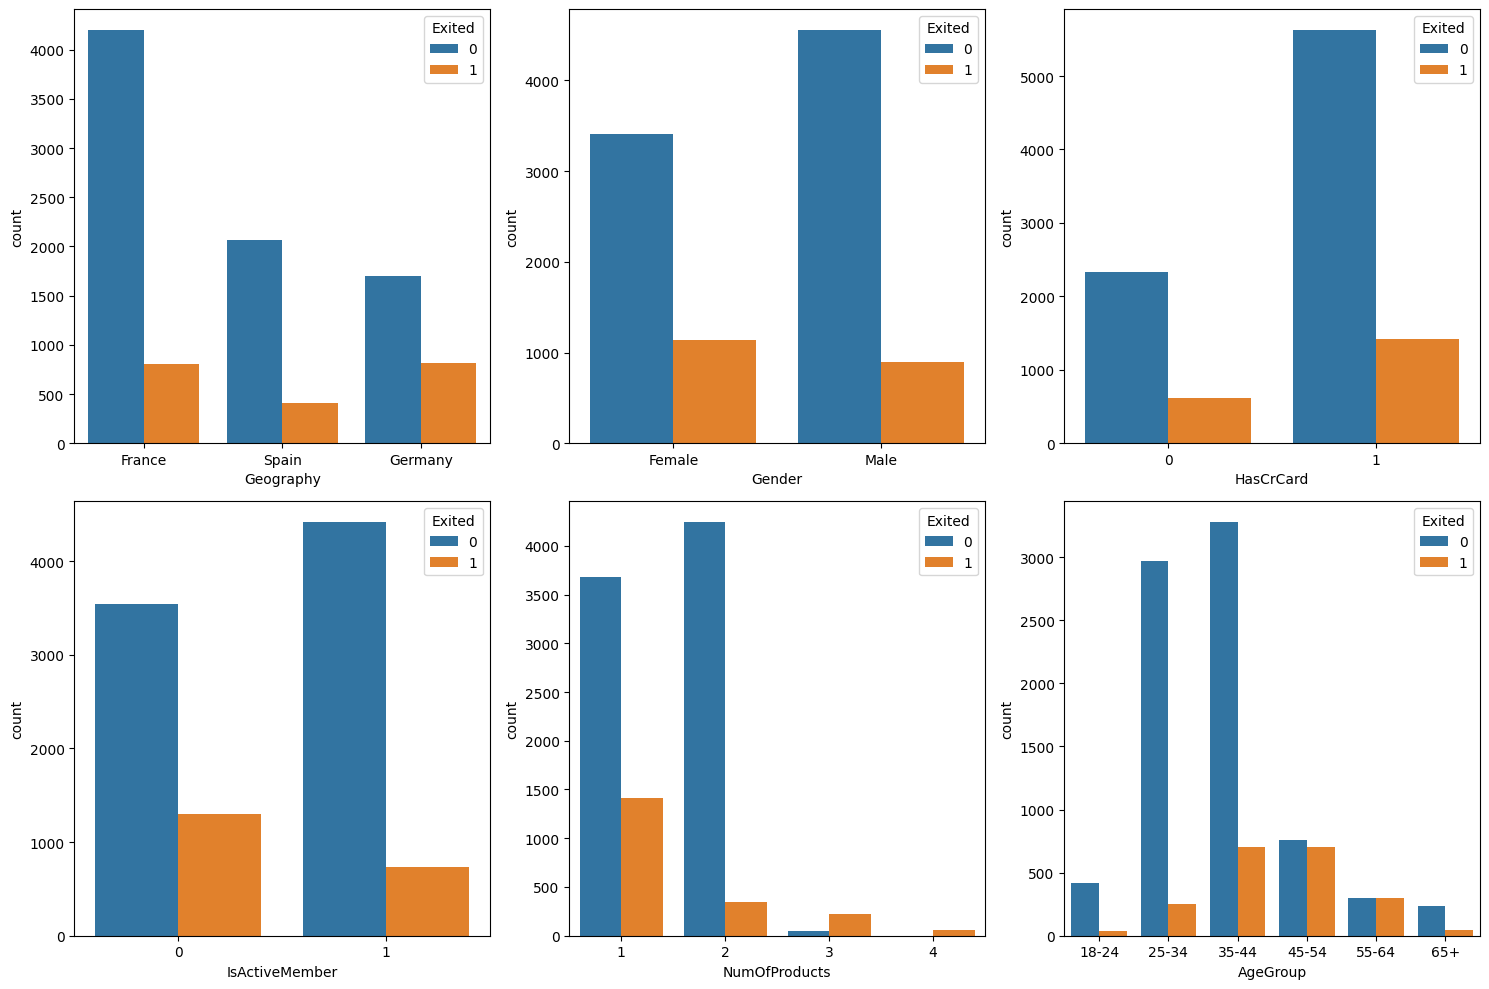

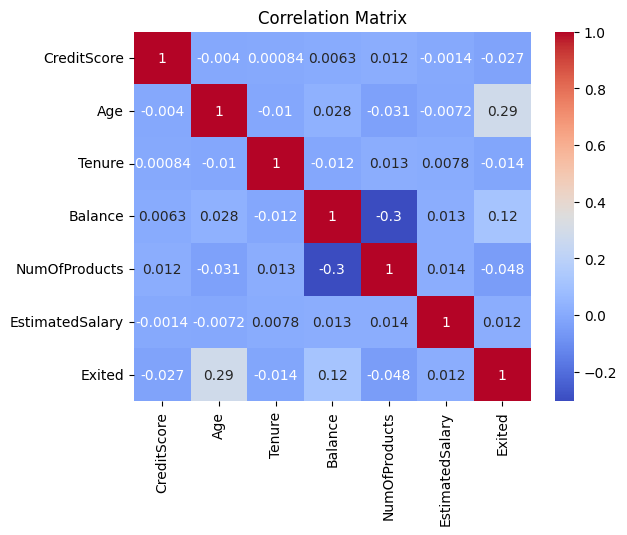

In [9]:
# Step 1: Visualize categorical variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sns.countplot(data=df, x='Geography', hue='Exited', ax=axes[0,0])
sns.countplot(data=df, x='Gender', hue='Exited', ax=axes[0,1])
sns.countplot(data=df, x='HasCrCard', hue='Exited', ax=axes[0,2])
sns.countplot(data=df, x='IsActiveMember', hue='Exited', ax=axes[1,0])
sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[1,1])
sns.countplot(data=df, x='AgeGroup', hue='Exited', ax=axes[1,2])
plt.tight_layout()
plt.show()

# Step 2: Analyze correlations
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()  

In [10]:
# Insights from the data analysis:

# 1. Age Distribution and Churn:
# - The majority of customers are in the 35-44 age group (3981 customers), followed by 25-34 (3222).
# - Age has a moderate positive correlation with churn (Exited: 0.285), indicating older customers are more likely to exit.

# 2. Categorical Variables and Churn:
# - From the countplots, customers in Germany have higher churn rates compared to France and Spain.
# - Males and females show similar churn patterns, but females might have slightly higher rates.
# - Inactive members (IsActiveMember=0) have higher churn.
# - Customers with fewer products (NumOfProducts=1) are more likely to churn.

# 3. Numerical Correlations:
# - Balance has a positive correlation with churn (0.119), suggesting customers with higher balances are more likely to exit.
# - Tenure and CreditScore have weak correlations with churn.
# - EstimatedSalary has almost no correlation with churn.

# 4. Other Observations:
# - No duplicate rows in the dataset.
# - Missing values: None apparent from earlier checks.
# - Dataset has 10,000 rows and 15 columns (including the added AgeGroup).

print("Key Insights:")
print("- Age is a significant factor in churn.")
print("- Geography (e.g., Germany) influences churn rates.")
print("- Balance and activity status correlate with exit likelihood.")

Key Insights:
- Age is a significant factor in churn.
- Geography (e.g., Germany) influences churn rates.
- Balance and activity status correlate with exit likelihood.


In [11]:
df.dtypes

RowNumber             int64
CustomerId            int64
Surname                 str
CreditScore           int64
Geography               str
Gender                  str
Age                   int64
Tenure                int64
Balance             float64
NumOfProducts         int64
HasCrCard             int64
IsActiveMember        int64
EstimatedSalary     float64
Exited                int64
AgeGroup           category
dtype: object

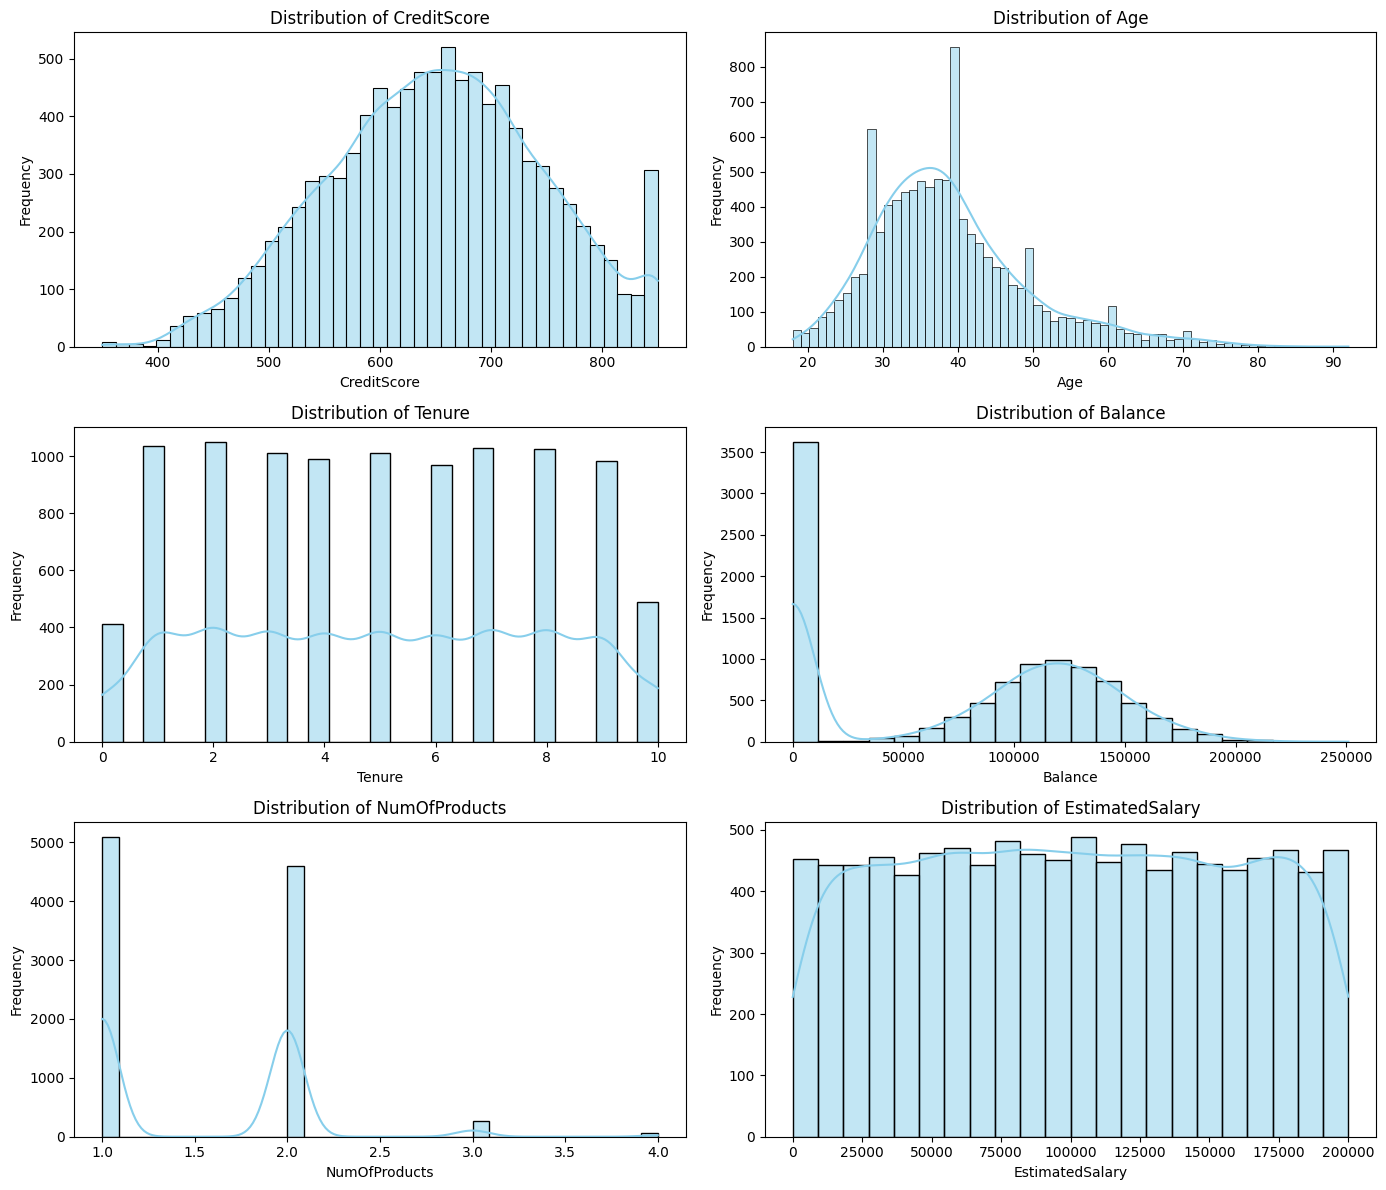

In [13]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()

In [14]:
for col in num_cols:
	Q1 = df[col].quantile(0.25)
	Q3 = df[col].quantile(0.75)
	IQR = Q3 - Q1
	lower_bound = Q1 - 1.5 * IQR
	upper_bound = Q3 + 1.5 * IQR
	outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
	print(f"Outliers in {col}: {len(outliers)}")
	if len(outliers) > 0:
		print(outliers[[col]].head())

Outliers in CreditScore: 15
      CreditScore
7             376
942           376
1193          363
1405          359
1631          350
Outliers in Age: 359
     Age
58    66
85    75
104   65
158   73
181   65
Outliers in Tenure: 0
Outliers in Balance: 0
Outliers in NumOfProducts: 60
      NumOfProducts
7                 4
70                4
1254              4
1469              4
1488              4
Outliers in EstimatedSalary: 0


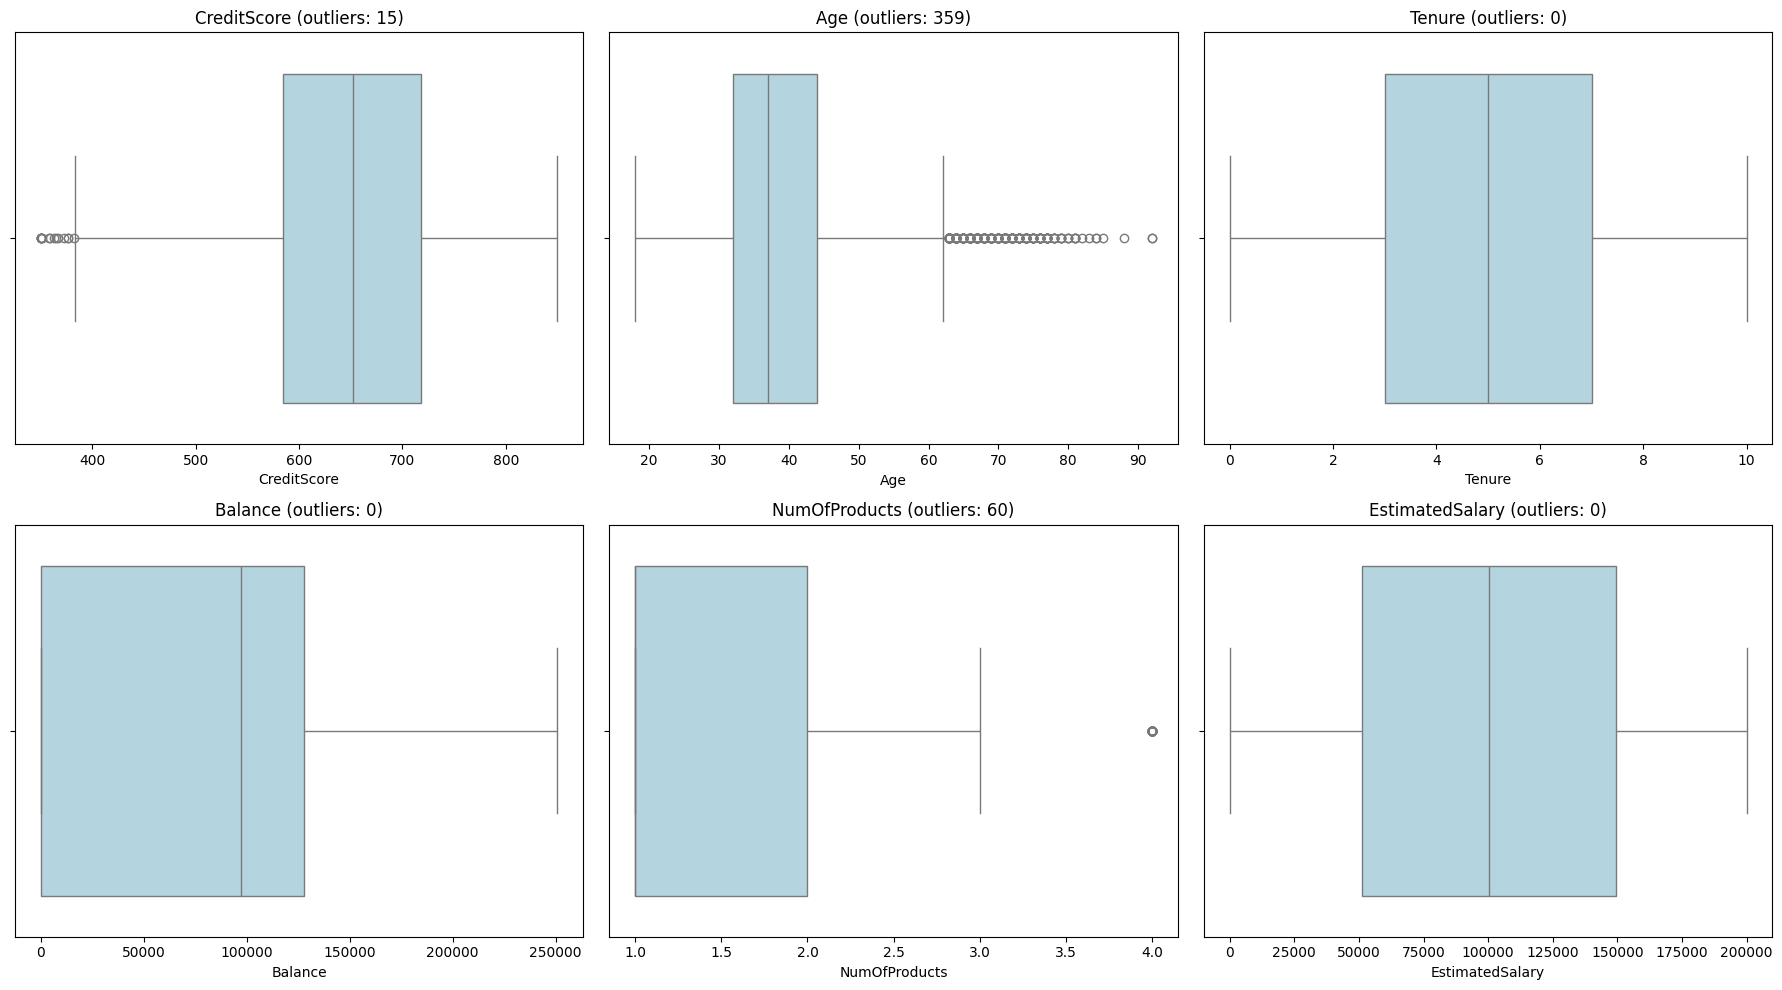

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax, color='lightblue')
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    ax.set_title(f'{col} (outliers: {outlier_count})')
    ax.set_xlabel(col)

plt.tight_layout()

NameError: name 'cat_cols' is not defined

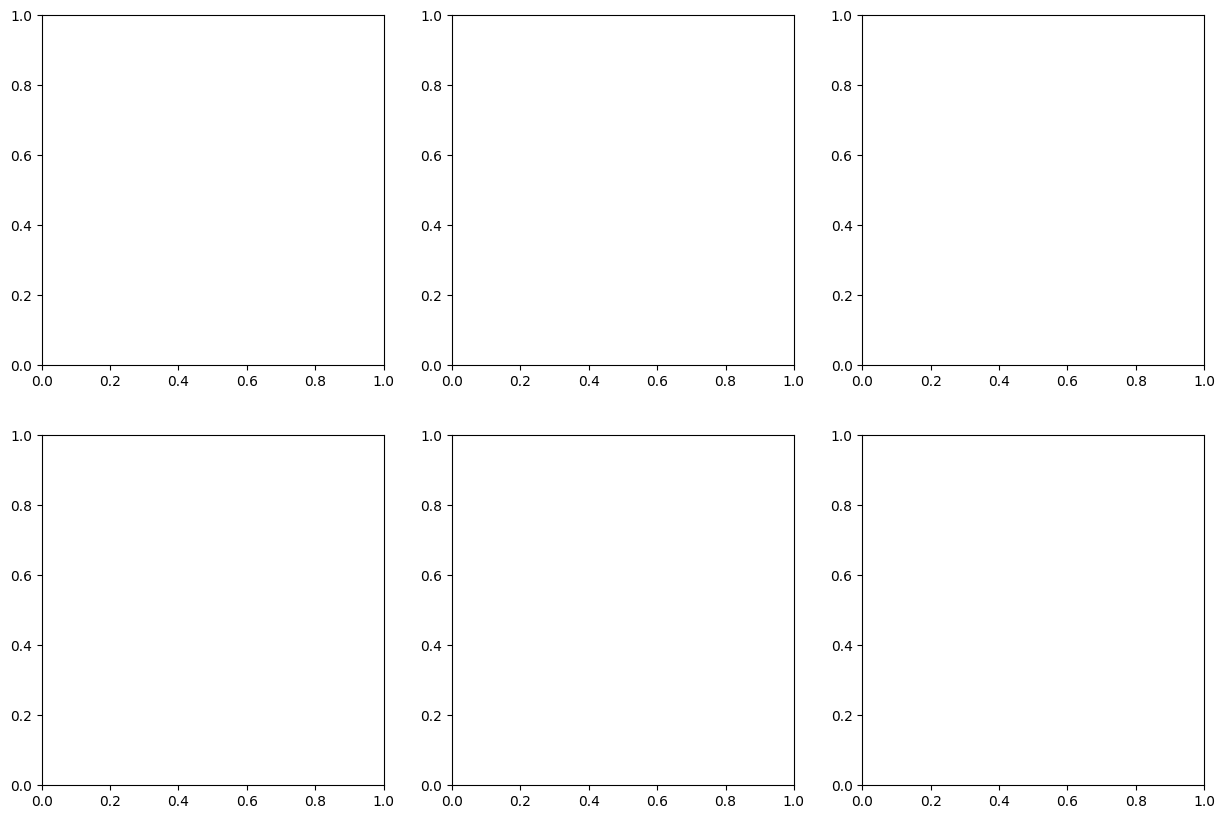

In [16]:
# Univariate analysis for categorical variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df, x=col, ax=ax)
plt.tight_layout()
plt.show()

                   count           mean           std     min       25%  \
CreditScore      10000.0     650.528800     96.653299  350.00    584.00   
Age              10000.0      38.921800     10.487806   18.00     32.00   
Tenure           10000.0       5.012800      2.892174    0.00      3.00   
Balance          10000.0   76485.889288  62397.405202    0.00      0.00   
NumOfProducts    10000.0       1.530200      0.581654    1.00      1.00   
EstimatedSalary  10000.0  100090.239881  57510.492818   11.58  51002.11   

                        50%          75%        max      skew  kurtosis  
CreditScore         652.000     718.0000     850.00 -0.071607 -0.425726  
Age                  37.000      44.0000      92.00  1.011320  1.395347  
Tenure                5.000       7.0000      10.00  0.010991 -1.165225  
Balance           97198.540  127644.2400  250898.09 -0.141109 -1.489412  
NumOfProducts         1.000       2.0000       4.00  0.745568  0.582981  
EstimatedSalary  100193.915  1

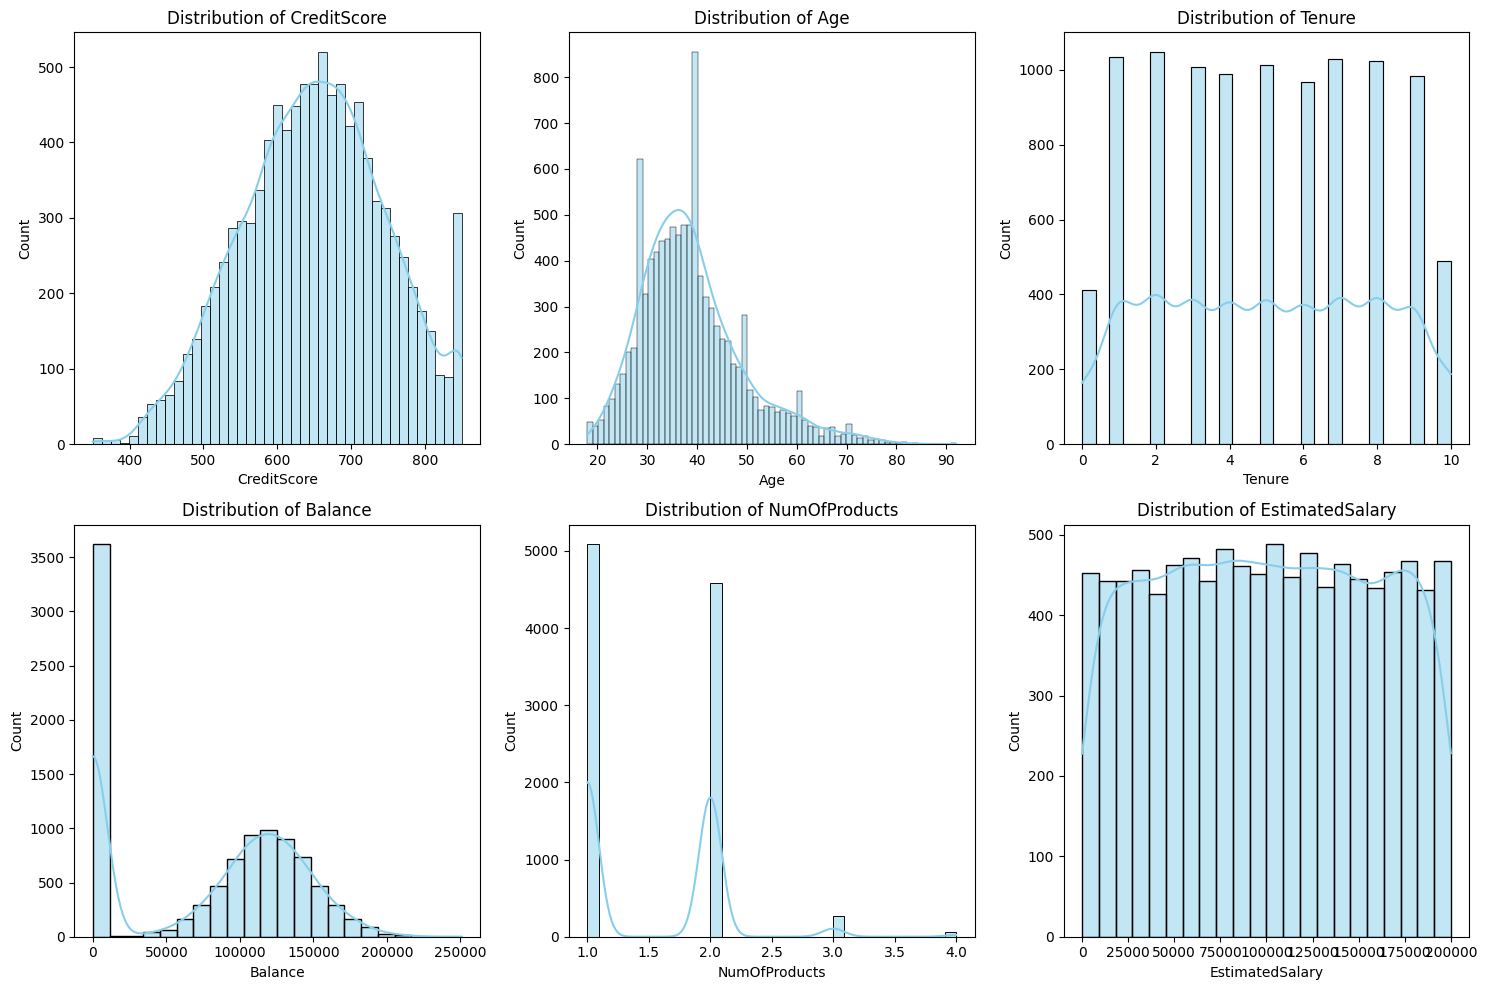

In [17]:
# Univariate analysis for numerical variables
num_stats = df[num_cols].describe().T
num_stats['skew'] = df[num_cols].skew()
num_stats['kurtosis'] = df[num_cols].kurtosis()
print(num_stats)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), num_cols):
	sns.histplot(df[col], kde=True, ax=ax, color='skyblue')
	ax.set_title(f'Distribution of {col}')
plt.tight_layout()

In [18]:
# Dataset Overview and Explanation

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n" + "="*60)
print("COLUMN DESCRIPTIONS")
print("="*60)

column_descriptions = {
    'CreditScore': 'Customer credit score (400-850 range typical)',
    'Geography': 'Country of residence (France, Germany, Spain)',
    'Gender': 'Customer gender (Male, Female)',
    'Age': 'Customer age in years',
    'Tenure': 'Number of years as a customer',
    'Balance': 'Account balance in dollars',
    'NumOfProducts': 'Number of products held by customer',
    'HasCrCard': 'Has credit card (1=Yes, 0=No)',
    'IsActiveMember': 'Is active member (1=Yes, 0=No)',
    'EstimatedSalary': 'Estimated annual salary in dollars',
    'Exited': 'Churn status (1=Exited, 0=Stayed)',
    'AgeGroup': 'Age grouped into bins (18-24, 25-34, etc.)'
}

for col, desc in column_descriptions.items():
    if col in df.columns:
        print(f"\n{col}: {desc}")
        print(f"  - Type: {df[col].dtype}")
        print(f"  - Unique Values: {df[col].nunique()}")
        print(f"  - Missing Values: {df[col].isnull().sum()}")

print("\n" + "="*60)
print("KEY STATISTICS")
print("="*60)
print(f"\nChurn Rate: {(df['Exited'].sum() / len(df) * 100):.2f}%")
print(f"Customers Retained: {(1 - df['Exited'].mean()) * 100:.2f}%")
print(f"\nAge Range: {df['Age'].min()} - {df['Age'].max()} years")
print(f"Average Tenure: {df['Tenure'].mean():.2f} years")

DATASET OVERVIEW

Dataset Shape: (10000, 15)
Total Rows: 10000
Total Columns: 15

COLUMN DESCRIPTIONS

CreditScore: Customer credit score (400-850 range typical)
  - Type: int64
  - Unique Values: 460
  - Missing Values: 0

Geography: Country of residence (France, Germany, Spain)
  - Type: str
  - Unique Values: 3
  - Missing Values: 0

Gender: Customer gender (Male, Female)
  - Type: str
  - Unique Values: 2
  - Missing Values: 0

Age: Customer age in years
  - Type: int64
  - Unique Values: 70
  - Missing Values: 0

Tenure: Number of years as a customer
  - Type: int64
  - Unique Values: 11
  - Missing Values: 0

Balance: Account balance in dollars
  - Type: float64
  - Unique Values: 6382
  - Missing Values: 0

NumOfProducts: Number of products held by customer
  - Type: int64
  - Unique Values: 4
  - Missing Values: 0

HasCrCard: Has credit card (1=Yes, 0=No)
  - Type: int64
  - Unique Values: 2
  - Missing Values: 0

IsActiveMember: Is active member (1=Yes, 0=No)
  - Type: int64
 

In [19]:
print(f"Numbers of null values in each column:")
for col in df.columns:
    print(f"  - {col}: {df[col].isnull().sum()}")

Numbers of null values in each column:
  - RowNumber: 0
  - CustomerId: 0
  - Surname: 0
  - CreditScore: 0
  - Geography: 0
  - Gender: 0
  - Age: 0
  - Tenure: 0
  - Balance: 0
  - NumOfProducts: 0
  - HasCrCard: 0
  - IsActiveMember: 0
  - EstimatedSalary: 0
  - Exited: 0
  - AgeGroup: 0


In [21]:
# Handle categorical features by identifying and encoding them
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'AgeGroup']

# One-hot encode categorical variables
encoded = pd.get_dummies(df[cat_cols], drop_first=True)

# Optionally, create a model-ready dataframe by combining numerical and encoded features
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']
model_df = pd.concat([df[numerical_cols], encoded], axis=1)

In [22]:
model_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,Exited,HasCrCard,IsActiveMember,NumOfProducts,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_25-34,AgeGroup_35-44,AgeGroup_45-54,AgeGroup_55-64,AgeGroup_65+
0,619,42,2,0.00,1,101348.88,1,1,1,1,False,False,False,False,True,False,False,False
1,608,41,1,83807.86,1,112542.58,0,0,1,1,False,True,False,False,True,False,False,False
2,502,42,8,159660.80,3,113931.57,1,1,0,3,False,False,False,False,True,False,False,False
3,699,39,1,0.00,2,93826.63,0,0,0,2,False,False,False,False,True,False,False,False
4,850,43,2,125510.82,1,79084.10,0,1,1,1,False,True,False,False,True,False,False,False


In [23]:
from sklearn.preprocessing import StandardScaler

# Select suitable numerical columns for scaling (continuous variables)
scale_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the selected columns
df[scale_cols] = scaler.fit_transform(df[scale_cols])